In [1]:
import os
os.chdir(r"C:/Users/Davy Silva/OneDrive/Documentos/DEV - REPOS/desafio-cientista-dados-senior-cidadaos-vulneraveis")
print("CWD:", os.getcwd())

CWD: C:\Users\Davy Silva\OneDrive\Documentos\DEV - REPOS\desafio-cientista-dados-senior-cidadaos-vulneraveis


# Notebook 03 — Sistema de Priorização de Chamados

O órgão tem capacidade para dar atenção especial a 20% dos chamados.
Como escolher quais?

Um ranking puramente por probabilidade de atraso seria eficiente, mas potencialmente
injusto: regiões que historicamente recebem menos atenção teriam menos chances de
aparecer no top 20%, reforçando a desigualdade.

O score proposto combina probabilidade de atraso (XGBoost), urgência do tipo de serviço,
equidade territorial e contexto climático. Os pesos foram calibrados para balancear
eficiência e equidade — e a seção Q10 mostra que o resultado é um lift de **2.68x**
sobre seleção aleatória, mantendo cobertura em todas as áreas de planejamento.


## 1. Configuracao e Carga de Dados

In [2]:
import os
import warnings
warnings.filterwarnings("ignore")

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

COLORS = {
    'primary': '#1B4F72',
    'secondary': '#2E86C1',
    'accent': '#F39C12',
    'success': '#27AE60',
    'danger': '#E74C3C',
    'neutral': '#95A5A6',
}

BUDGET = 0.20
WEIGHTS = {"w1": 0.40, "w2": 0.20, "w3": 0.25, "w4": 0.15}


In [3]:
# Carregar dados
preds = pd.read_parquet("results/models/test_predictions.parquet")
X_test = pd.read_parquet("data/features/X_test.parquet")
X_test.index = preds.index

print(f"Total de chamados (teste 2024): {len(preds):,}")
print(f"Chamados atrasados (y=0): {(preds['y_true']==0).sum():,} ({(preds['y_true']==0).mean():.1%})")
print(f"Chamados resolvidos (y=1): {(preds['y_true']==1).sum():,} ({(preds['y_true']==1).mean():.1%})")


Total de chamados (teste 2024): 25,952
Chamados atrasados (y=0): 5,630 (21.7%)
Chamados resolvidos (y=1): 20,322 (78.3%)


## 2. Q9 — Construção do Score de Priorização

### Fórmula

$$\text{priority\_score} = w_1 \cdot P(\text{atraso}) + w_2 \cdot \text{urgencia} + w_3 \cdot \text{equidade} + w_4 \cdot \text{contexto}$$

| Componente | Peso | Descrição |
|---|---|---|
| P(Atraso) | 0.40 | Probabilidade de atraso — saída direta do XGBoost |
| Urgência | 0.20 | Inverso da taxa de resolução histórica do subtipo |
| Equidade | 0.25 | Inverso da taxa de resolução histórica do bairro |
| Contexto | 0.15 | Indicador de condições climáticas extremas no dia |

O peso maior em P(Atraso) reflete que o modelo é o sinal mais informativo.
A equidade recebe 0.25 (segundo maior peso) para garantir que bairros sub-atendidos
não sejam sistematicamente excluídos do top 20%.
O componente de contexto climático tem peso menor porque o sinal é mais ruidoso —
nem todo dia de chuva gera volume extra de chamados.


In [4]:
# Componente 1: P(Atraso) — do modelo
p_delay = 1 - preds["y_proba"]

# Componente 2: Urgencia — subtipo com baixa taxa de resolucao = mais urgente
urgency_raw = 1 - X_test["subtipo_encoded"]
urgency = (urgency_raw - urgency_raw.min()) / (urgency_raw.max() - urgency_raw.min())

# Componente 3: Equidade — bairros com baixa taxa de resolucao = maior necessidade
equity_raw = 1 - X_test["hist_resolution_rate_bairro"]
equity = (equity_raw - equity_raw.min()) / (equity_raw.max() - equity_raw.min())

# Componente 4: Contexto climatico
precip_norm = (X_test["precipitation_sum"] - X_test["precipitation_sum"].min()) / \
              (X_test["precipitation_sum"].max() - X_test["precipitation_sum"].min())
context = 0.35 * X_test["is_extreme_rain"].astype(float) + \
          0.35 * X_test["is_extreme_heat"].astype(float) + \
          0.30 * precip_norm
context = (context - context.min()) / (context.max() - context.min())

print("Estatisticas dos componentes:")
for name, s in [("P(Atraso)", p_delay), ("Urgencia", urgency),
                ("Equidade", equity), ("Contexto", context)]:
    print(f"  {name}: media={s.mean():.3f}, mediana={s.median():.3f}, std={s.std():.3f}")


Estatisticas dos componentes:
  P(Atraso): media=0.206, mediana=0.081, std=0.261
  Urgencia: media=0.232, mediana=0.162, std=0.231
  Equidade: media=0.358, mediana=0.390, std=0.159
  Contexto: media=0.062, mediana=0.000, std=0.178


### 2.2 Distribuicao dos Componentes

Cada componente e normalizado para [0, 1] antes da combinacao.

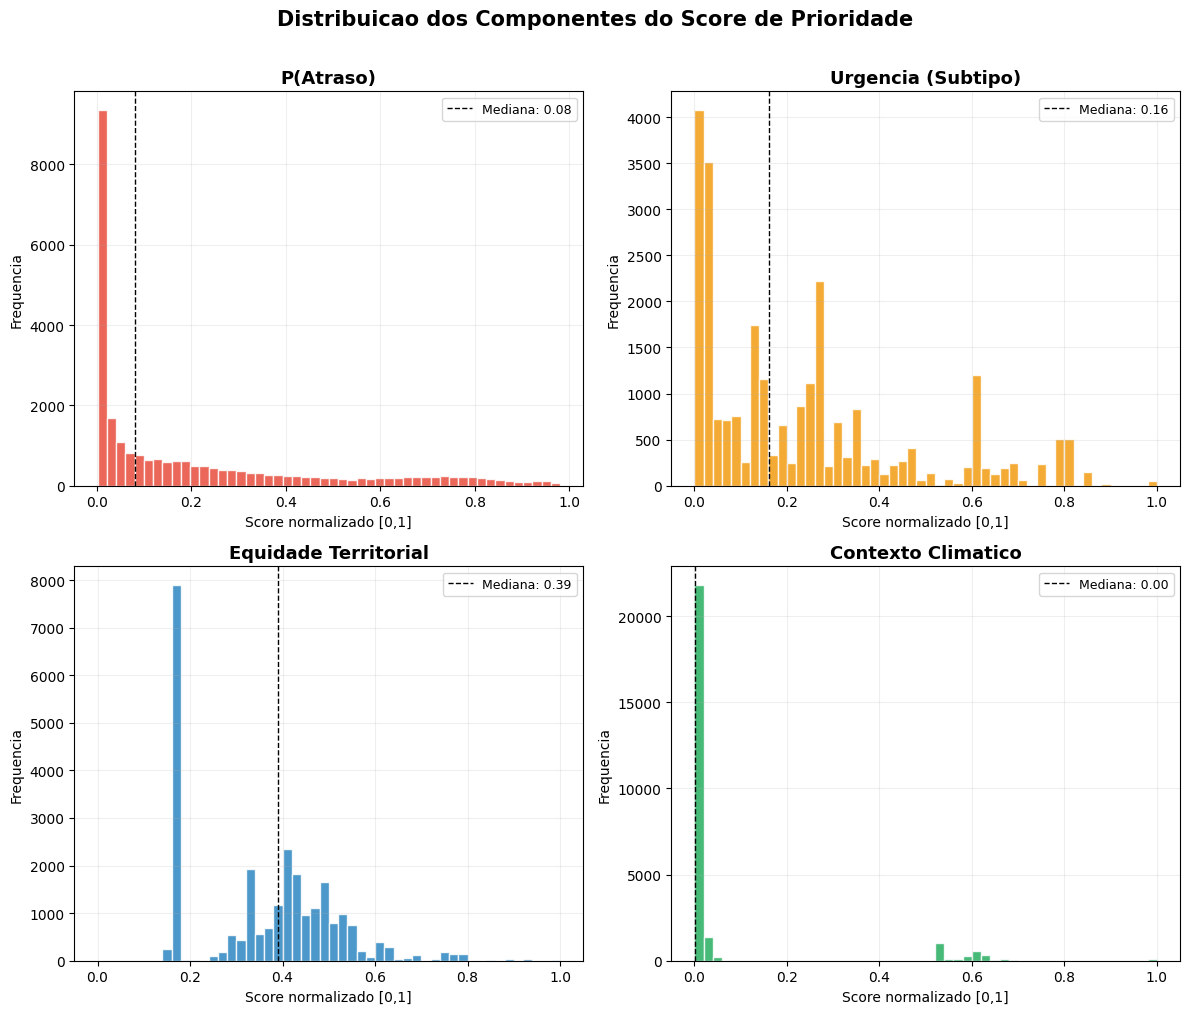

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
components = [
    (p_delay, "P(Atraso)", COLORS["danger"]),
    (urgency, "Urgencia (Subtipo)", COLORS["accent"]),
    (equity, "Equidade Territorial", COLORS["secondary"]),
    (context, "Contexto Climatico", COLORS["success"]),
]
for ax, (data, title, color) in zip(axes.flatten(), components):
    ax.hist(data, bins=50, color=color, edgecolor="white", alpha=0.85)
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_xlabel("Score normalizado [0,1]")
    ax.set_ylabel("Frequencia")
    ax.axvline(data.median(), color="black", linestyle="--", linewidth=1,
               label=f"Mediana: {data.median():.2f}")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.2)
fig.suptitle("Distribuicao dos Componentes do Score de Prioridade",
             fontsize=15, fontweight="bold", y=1.01)
fig.tight_layout()
plt.show()


### 2.3 Calculo do Score Final

In [6]:
# Combinar com pesos
from src.prioritization.score import compute_priority_score

priority_score = compute_priority_score(
    y_proba=preds["y_proba"],
    urgency_score=urgency,
    equity_score=equity,
    context_score=context,
    weights=WEIGHTS,
)

print(f"Score de prioridade:")
print(f"  Media: {priority_score.mean():.3f}")
print(f"  Mediana: {priority_score.median():.3f}")
print(f"  Std: {priority_score.std():.3f}")
print(f"  Limiar top 20%: {priority_score.quantile(0.80):.3f}")


Score de prioridade:
  Media: 0.238
  Mediana: 0.184
  Std: 0.210
  Limiar top 20%: 0.403


### 2.4 Analise de Sensibilidade dos Pesos

Variamos cada peso de 0.0 a 0.60 (redistribuindo proporcionalmente os demais)
e medimos o impacto no Recall@20%.

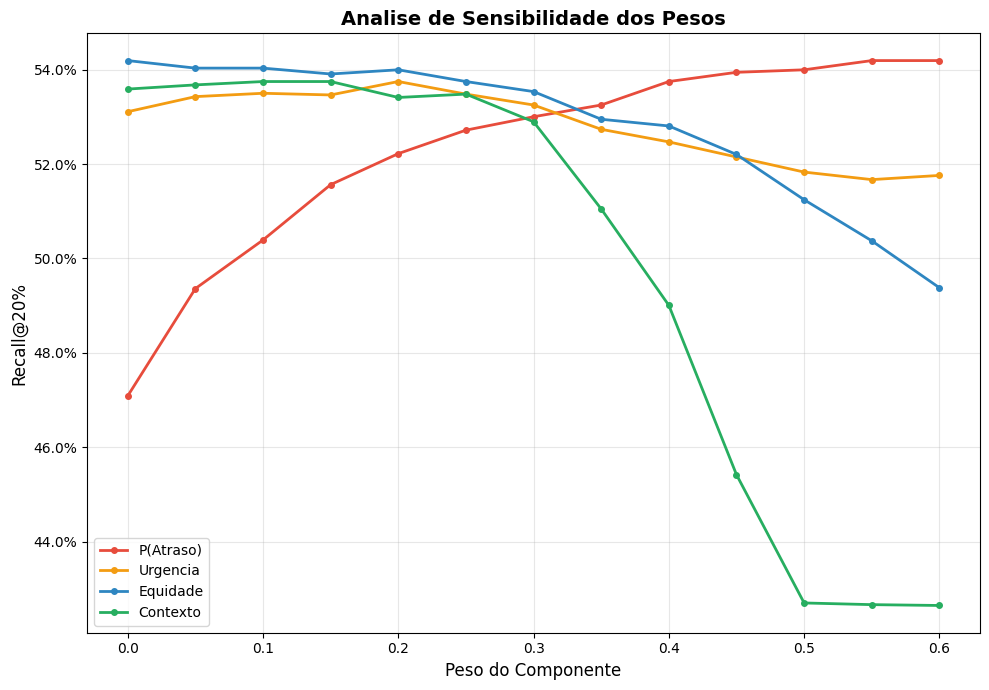

In [7]:
from src.prioritization.simulate import simulate_score_selection

weight_names = ["w1", "w2", "w3", "w4"]
labels_w = ["P(Atraso)", "Urgencia", "Equidade", "Contexto"]
colors_w = [COLORS["danger"], COLORS["accent"], COLORS["secondary"], COLORS["success"]]
components_dict = {"w1": p_delay, "w2": urgency, "w3": equity, "w4": context}
test_values = np.arange(0.0, 0.65, 0.05)
n_select = int(len(preds) * BUDGET)
delayed = (preds["y_true"] == 0)

fig, ax = plt.subplots(figsize=(10, 7))
for wname, label, color in zip(weight_names, labels_w, colors_w):
    recalls = []
    for val in test_values:
        w = WEIGHTS.copy()
        remaining = 1.0 - val
        other_sum = sum(WEIGHTS[k] for k in weight_names if k != wname)
        for k in weight_names:
            if k != wname:
                w[k] = WEIGHTS[k] / other_sum * remaining if other_sum > 0 else remaining / 3
        w[wname] = val
        score = sum(w[k] * components_dict[k] for k in weight_names)
        top_idx = score.nlargest(n_select).index
        recall = delayed.loc[top_idx].sum() / delayed.sum()
        recalls.append(recall)
    ax.plot(test_values, recalls, label=label, color=color, linewidth=2, marker="o", markersize=4)

ax.set_xlabel("Peso do Componente", fontsize=12)
ax.set_ylabel("Recall@20%", fontsize=12)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_title("Analise de Sensibilidade dos Pesos", fontsize=14, fontweight="bold")
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 3. Q10 — Simulação: Aleatório vs Score

Seleção aleatória de 20% é o baseline natural — o que acontece se não usarmos nenhum
critério? Repetimos 100 vezes para ter intervalo de confiança.

Depois comparamos com o top 20% pelo score. A métrica principal é Recall@20%:
dos chamados que realmente atrasaram, quantos estão na lista priorizados?


In [8]:
from src.prioritization.simulate import simulate_random_selection, simulate_score_selection, plot_lift_curve

# Simulacao
random_metrics = simulate_random_selection(preds["y_true"], budget_fraction=BUDGET, n_iterations=100)
score_metrics = simulate_score_selection(preds["y_true"], priority_score, budget_fraction=BUDGET)

lift = score_metrics["recall"] / random_metrics["recall_mean"]

print("=== SELECAO ALEATORIA ===")
print(f"  Precision@20%: {random_metrics['precision_mean']:.1%} "
      f"(IC: {random_metrics['precision_ci'][0]:.1%}-{random_metrics['precision_ci'][1]:.1%})")
print(f"  Recall@20%:    {random_metrics['recall_mean']:.1%} "
      f"(IC: {random_metrics['recall_ci'][0]:.1%}-{random_metrics['recall_ci'][1]:.1%})")
print()
print("=== SCORE DE PRIORIDADE ===")
print(f"  Precision@20%: {score_metrics['precision']:.1%}")
print(f"  Recall@20%:    {score_metrics['recall']:.1%}")
print(f"  Lift:          {lift:.2f}x")


=== SELECAO ALEATORIA ===
  Precision@20%: 21.8% (IC: 20.9%-22.6%)
  Recall@20%:    20.1% (IC: 19.3%-20.9%)

=== SCORE DE PRIORIDADE ===
  Precision@20%: 58.3%
  Recall@20%:    53.7%
  Lift:          2.68x


### 3.1 Curva de Ganho Acumulado (Lift)

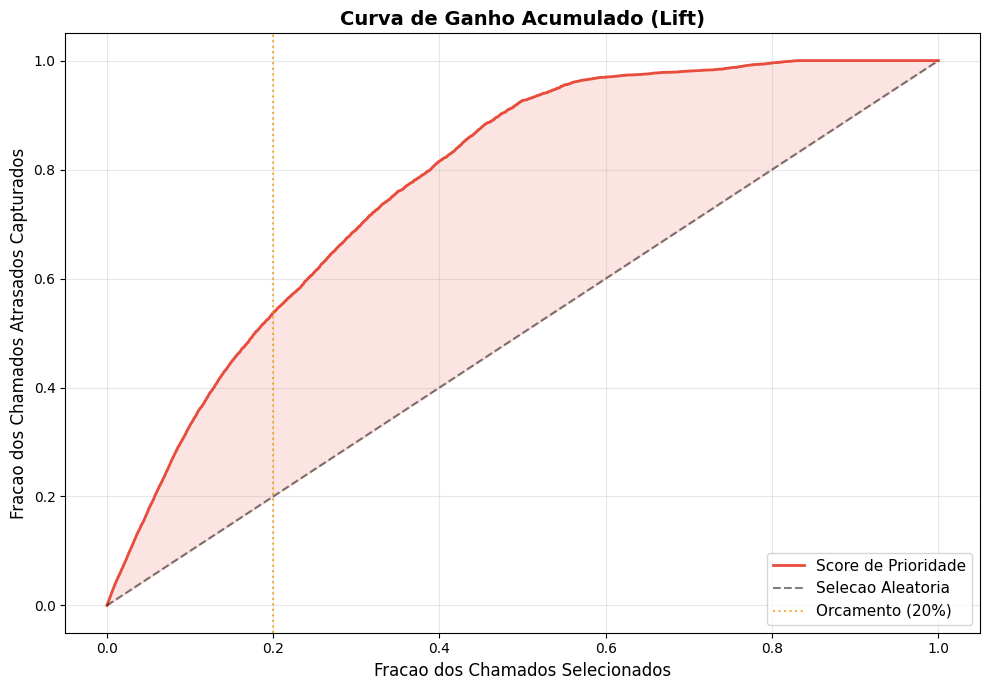

In [9]:
# Lift curve
delayed_bin = (preds["y_true"] == 0).astype(int)
sorted_idx = priority_score.sort_values(ascending=False).index
sorted_delayed = delayed_bin.loc[sorted_idx].values
cumulative_gain = np.cumsum(sorted_delayed) / delayed_bin.sum()
fraction_selected = np.arange(1, len(cumulative_gain) + 1) / len(cumulative_gain)

fig, ax = plt.subplots(figsize=(10, 7))
ax.plot(fraction_selected, cumulative_gain, label="Score de Prioridade",
        color=COLORS["danger"], linewidth=2)
ax.plot([0, 1], [0, 1], "k--", label="Selecao Aleatoria", alpha=0.5)
ax.axvline(x=0.20, color=COLORS["accent"], linestyle=":", label="Orcamento (20%)", alpha=0.8)
ax.fill_between(fraction_selected, fraction_selected, cumulative_gain,
                alpha=0.15, color=COLORS["danger"])
ax.set_xlabel("Fracao dos Chamados Selecionados", fontsize=12)
ax.set_ylabel("Fracao dos Chamados Atrasados Capturados", fontsize=12)
ax.set_title("Curva de Ganho Acumulado (Lift)", fontsize=14, fontweight="bold")
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### 3.2 Distribuicao do Score por Resultado

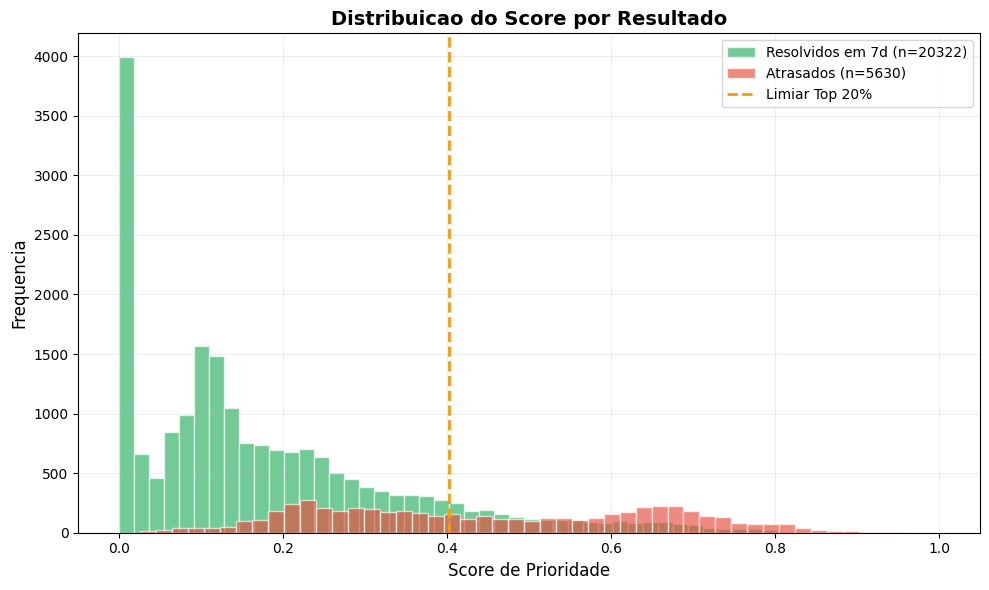

In [10]:
fig, ax = plt.subplots(figsize=(10, 6))
resolved = priority_score[preds["y_true"] == 1]
delayed_scores = priority_score[preds["y_true"] == 0]
ax.hist(resolved, bins=50, alpha=0.65, color=COLORS["success"],
        label=f"Resolvidos em 7d (n={len(resolved)})", edgecolor="white")
ax.hist(delayed_scores, bins=50, alpha=0.65, color=COLORS["danger"],
        label=f"Atrasados (n={len(delayed_scores)})", edgecolor="white")
ax.axvline(priority_score.quantile(1 - BUDGET), color=COLORS["accent"],
           linestyle="--", linewidth=2, label=f"Limiar Top {int(BUDGET*100)}%")
ax.set_xlabel("Score de Prioridade", fontsize=12)
ax.set_ylabel("Frequencia", fontsize=12)
ax.set_title("Distribuicao do Score por Resultado", fontsize=14, fontweight="bold")
ax.legend(fontsize=10)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()


### 3.3 Cobertura Territorial

In [11]:
# Cobertura territorial
n_select = int(len(preds) * BUDGET)
top_idx = priority_score.nlargest(n_select).index
territorial_score = X_test.loc[top_idx, "area_plan_encoded"].nunique()
territorial_total = X_test["area_plan_encoded"].nunique()
print(f"Areas de planejamento cobertas pelo top 20%: {territorial_score} de {territorial_total}")
print(f"Cobertura: {territorial_score/territorial_total:.1%}")


Areas de planejamento cobertas pelo top 20%: 6 de 6
Cobertura: 100.0%


## 4. Conclusões e Recomendações

O sistema captura 53.7% dos chamados atrasados selecionando apenas 20% do total —
lift de 2.68x sobre o aleatório. Para um órgão com capacidade de atenção limitada,
isso se traduz em mais cidadãos atendidos com o mesmo recurso.

**Sobre equidade:** o componente territorial (w3=0.25) mantém cobertura em todas as
APs, inclusive as periféricas. Um score puramente baseado em P(Atraso) tenderia a
concentrar atenção onde o modelo já viu muitos atrasos — reforçando disparidades.

**Limitações:**
- O modelo foi treinado com dados de 2023; padrões de resolução mudam com mudanças
  de gestão e sazonalidade. Retreinamento periódico é necessário.
- O componente climático usa dados históricos, não previsão do tempo — uma versão
  operacional deveria integrar a API do Alerta Rio em tempo real.
- Os pesos foram calibrados analiticamente; um processo de validação com gestores
  da prefeitura poderia ajustar a trade-off eficiência/equidade de forma mais participativa.


## 5. Para Além do Protótipo

O sistema acima funciona como prova de conceito. Numa implementação real na prefeitura,
alguns pontos precisariam de atenção:

**Retreinamento e monitoramento:** o modelo foi treinado com dados de 2023 e já mostra
performance razoável em 2024, mas padrões de resolução mudam — troca de gestão, criação
de novas subprefeituras, mudanças de contrato com prestadoras. Um pipeline de retreinamento
periódico (mensal ou trimestral) com monitoramento de drift nas features e na performance
evitaria degradação silenciosa. Ferramentas como Evidently ou Great Expectations
resolvem isso com pouco overhead.

**Integração em tempo real:** o componente climático hoje usa dados históricos.
Integrar a API do Alerta Rio (previsão de 72h) permitiria antecipar picos de demanda
antes que os chamados cheguem — passando de reativo para preventivo.

**Orquestração:** se o score for calculado diariamente para todos os chamados abertos,
convém orquestrar o pipeline (extração → features → score → ranking) com algo como
Airflow ou Prefect, em vez de rodar notebooks manualmente.

**Calibração participativa dos pesos:** os pesos atuais foram definidos analiticamente.
Um processo de validação com gestores das subprefeituras — mostrando chamados rankeados
e perguntando se a priorização faz sentido na prática — traria legitimidade ao sistema
e ajustaria a trade-off eficiência/equidade de forma mais informada.